In [1]:
import numpy as np
import pandas as pd
from IPython.display import display
import warnings
import platform
import matplotlib.pyplot as plt

# 출력 설정
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [3]:
# ============================================================
# 1. 원본 데이터 로드
# ============================================================
df_merged = pd.read_csv("clean_data/starbucks_merge.csv", index_col=0)


# ============================================================
# 2. 데이터 기본 구조 확인
# ============================================================
print("===== 기본 크기 확인 =====")
print("\n[merged]")
print("shape :", df_merged.shape)
display(df_merged.head())
print()

===== 기본 크기 확인 =====

[merged]
shape : (306137, 19)


,event,time,offer_id,amount,event_reward,offer_type,offer_reward,difficulty,duration,channels,web,email,mobile,social,gender,age,income,became_member_on,value
customer_id,,,,,,,,,,,,,,,,,,,
78afa995795e4d85b5d9ceeca43f5fef,offer received,0,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,NaN,bogo,5.0,5.0,7.0,"['web', 'email', 'mobile']",1.0,1.0,1.0,0.0,F,75.0,100000.0,2017-05-09,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'}
a03223e636434f42ac4c3df47e8bac43,offer received,0,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN,discount,5.0,20.0,10.0,"['web', 'email']",1.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'}
e2127556f4f64592b11af22de27a7932,offer received,0,2906b810c7d4411798c6938adc9daaa5,NaN,NaN,discount,2.0,10.0,7.0,"['web', 'email', 'mobile']",1.0,1.0,1.0,0.0,M,68.0,70000.0,2018-04-26,{'offer id': '2906b810c7d4411798c6938adc9daaa5'}
8ec6ce2a7e7949b1bf142def7d0e0586,offer received,0,fafdcd668e3743c1bb461111dcafc2a4,NaN,NaN,discount,2.0,10.0,10.0,"['web', 'email', 'mobile', 'social']",1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'}
68617ca6246f4fbc85e91a2a49552598,offer received,0,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,NaN,bogo,10.0,10.0,5.0,"['web', 'email', 'mobile', 'social']",1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'}


In [5]:
print(df_merged.columns)
print(df_merged.head())

Index(['event', 'time', 'offer_id', 'amount', 'event_reward', 'offer_type',
       'offer_reward', 'difficulty', 'duration', 'channels', 'web', 'email',
       'mobile', 'social', 'gender', 'age', 'income', 'became_member_on',
       'value'],
      dtype='str')
                                           event  time  \
customer_id                                              
78afa995795e4d85b5d9ceeca43f5fef  offer received     0   
a03223e636434f42ac4c3df47e8bac43  offer received     0   
e2127556f4f64592b11af22de27a7932  offer received     0   
8ec6ce2a7e7949b1bf142def7d0e0586  offer received     0   
68617ca6246f4fbc85e91a2a49552598  offer received     0   

                                                          offer_id  amount  \
customer_id                                                                  
78afa995795e4d85b5d9ceeca43f5fef  9b98b8c7a33c4b65b9aebfe6a799e6d9     NaN   
a03223e636434f42ac4c3df47e8bac43  0b1e1539f2cc45b7b9fa7c272da2e1d7     NaN   
e2127556f4f64592b1

In [6]:
df_merged = df_merged.reset_index()
print(df_merged.columns)

Index(['customer_id', 'event', 'time', 'offer_id', 'amount', 'event_reward',
       'offer_type', 'offer_reward', 'difficulty', 'duration', 'channels',
       'web', 'email', 'mobile', 'social', 'gender', 'age', 'income',
       'became_member_on', 'value'],
      dtype='str')


In [7]:
# offer received
df_received = df_merged[df_merged["event"] == "offer received"]

# offer completed
df_completed = df_merged[df_merged["event"] == "offer completed"]

# offer_id 기준 집계
received = df_received.groupby("offer_id")["customer_id"].nunique()
completed = df_completed.groupby("offer_id")["customer_id"].nunique()

conversion_df = pd.concat([received, completed], axis=1)
conversion_df.columns = ["received", "completed"]

conversion_df["conversion_rate"] = (
    conversion_df["completed"] / conversion_df["received"]
)

print(conversion_df)

                                  received  completed  conversion_rate
offer_id                                                              
0b1e1539f2cc45b7b9fa7c272da2e1d7      6374     2978.0         0.467211
2298d6c36e964ae4a3e7e9706d1fb8c2      6325     4421.0         0.698972
2906b810c7d4411798c6938adc9daaa5      6285     3480.0         0.553699
3f207df678b143eea3cee63160fa8bed      6331        NaN              NaN
4d5c57ea9a6940dd891ad53e9dbe8da0      6330     2885.0         0.455766
5a8bc65990b245e5a138643cd4eb9837      6320        NaN              NaN
9b98b8c7a33c4b65b9aebfe6a799e6d9      6355     3784.0         0.595437
ae264e3637204a6fb9bb56bc8210ddfd      6374     3177.0         0.498431
f19421c1d4aa40978ebb69ca19b0e20d      6262     3741.0         0.597413
fafdcd668e3743c1bb461111dcafc2a4      6332     4530.0         0.715414


In [8]:
# 전환 고객 리스트
converted_customers = df_completed["customer_id"].unique()

# 라벨링
df_merged["converted"] = df_merged["customer_id"].isin(converted_customers).astype(int)

In [9]:
# viewed
df_viewed = df_merged[df_merged["event"] == "offer viewed"]

viewed = df_viewed.groupby("offer_id")["customer_id"].nunique()

conversion_df["viewed"] = viewed

# viewed → completed 전환율
conversion_df["view_to_complete_rate"] = (
    conversion_df["completed"] / conversion_df["viewed"]
)

In [10]:
# 1. 이벤트별 데이터 분리
df_received = df_merged[df_merged["event"] == "offer received"]
df_viewed = df_merged[df_merged["event"] == "offer viewed"]
df_completed = df_merged[df_merged["event"] == "offer completed"]

# 2. offer 기준 집계
received = df_received.groupby("offer_id")["customer_id"].nunique()
viewed = df_viewed.groupby("offer_id")["customer_id"].nunique()
completed = df_completed.groupby("offer_id")["customer_id"].nunique()

# 3. 하나로 합치기
funnel_df = pd.concat([received, viewed, completed], axis=1)
funnel_df.columns = ["received", "viewed", "completed"]

# 4. 전환율 계산
funnel_df["view_rate"] = funnel_df["viewed"] / funnel_df["received"]
funnel_df["completion_rate"] = funnel_df["completed"] / funnel_df["viewed"]
funnel_df["total_conversion_rate"] = funnel_df["completed"] / funnel_df["received"]

# 보기 좋게 정리
funnel_df = funnel_df.fillna(0)

print(funnel_df)

                                  received  viewed  completed  view_rate  \
offer_id                                                                   
0b1e1539f2cc45b7b9fa7c272da2e1d7      6374    2400     2978.0   0.376530   
2298d6c36e964ae4a3e7e9706d1fb8c2      6325    6122     4421.0   0.967905   
2906b810c7d4411798c6938adc9daaa5      6285    3608     3480.0   0.574065   
3f207df678b143eea3cee63160fa8bed      6331    3635        0.0   0.574159   
4d5c57ea9a6940dd891ad53e9dbe8da0      6330    6132     2885.0   0.968720   
5a8bc65990b245e5a138643cd4eb9837      6320    5674        0.0   0.897785   
9b98b8c7a33c4b65b9aebfe6a799e6d9      6355    3658     3784.0   0.575610   
ae264e3637204a6fb9bb56bc8210ddfd      6374    5696     3177.0   0.893630   
f19421c1d4aa40978ebb69ca19b0e20d      6262    6060     3741.0   0.967742   
fafdcd668e3743c1bb461111dcafc2a4      6332    6150     4530.0   0.971257   

                                  completion_rate  total_conversion_rate  
offer_id    

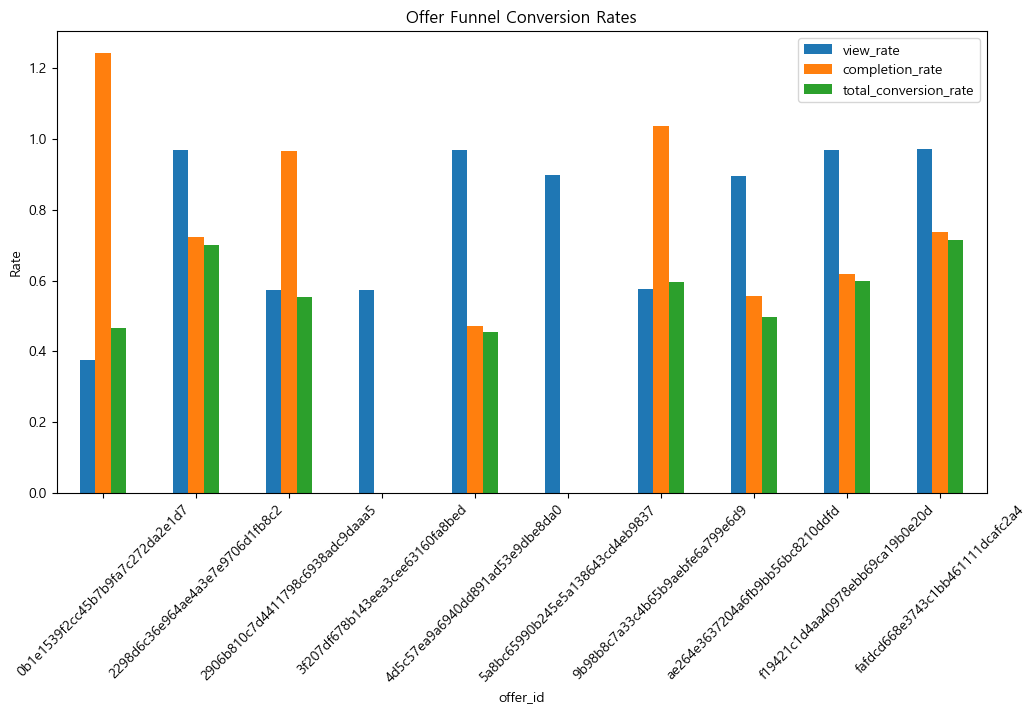

In [11]:
import matplotlib.pyplot as plt

funnel_df[["view_rate", "completion_rate", "total_conversion_rate"]].plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Offer Funnel Conversion Rates")
plt.ylabel("Rate")
plt.xticks(rotation=45)
plt.show()

In [12]:
funnel_type = df_merged.groupby(["offer_type", "event"])["customer_id"].nunique().unstack().fillna(0)

funnel_type["view_rate"] = funnel_type["offer viewed"] / funnel_type["offer received"]
funnel_type["completion_rate"] = funnel_type["offer completed"] / funnel_type["offer viewed"]
funnel_type["total_conversion_rate"] = funnel_type["offer completed"] / funnel_type["offer received"]

print(funnel_type)

event          offer completed  offer received  offer viewed  view_rate  \
offer_type                                                                
bogo                    9263.0         14992.0       14008.0   0.934365   
discount               10289.0         14945.0       12676.0   0.848177   
informational              0.0         10547.0        8251.0   0.782308   

event          completion_rate  total_conversion_rate  
offer_type                                             
bogo                  0.661265               0.617863  
discount              0.811691               0.688458  
informational         0.000000               0.000000  


<Axes: xlabel='offer_type'>

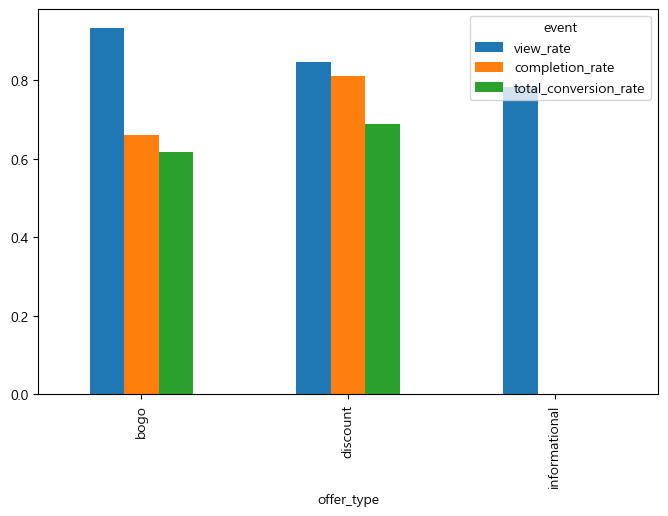

In [13]:
funnel_type[["view_rate", "completion_rate", "total_conversion_rate"]].plot(
    kind="bar",
    figsize=(8,5)
)

[view_rate (노출 → 확인)]
bogo: 0.93 (매우 높음)
discount: 0.85
informational: 0.78

=> “무료/보상형(bogo)이 클릭을 잘 유도함”


[completion_rate (확인 → 구매)]
bogo: 0.66
discount: 0.81 (압도적 1위)

=> discount는 본 순간 거의 산다 => 할인은 구매를 직접 유도하는 힘이 강함
bogo는 관심 대비 구매는 약간 떨어짐


[total_conversion_rate (최종)]
bogo: 0.61
discount: 0.68 (최고)

결론: discount 오퍼가 최고다